In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

2026-03-24 18:39:11.465743: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
# ==========================================
# 1. 读取与特征选择 (Data Loading & Feature Selection)
# ==========================================
# 读取单站点数据
df = pd.read_csv('station05.csv')

# 先把时间列转为 datetime，并构造周期时间特征
df['date_time'] = pd.to_datetime(df['date_time'])
hour = df['date_time'].dt.hour + df['date_time'].dt.minute / 60.0
doy = df['date_time'].dt.dayofyear
df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
df['doy_sin'] = np.sin(2 * np.pi * doy / 365)
df['doy_cos'] = np.cos(2 * np.pi * doy / 365)

# 风向属于角度变量，用正余弦编码比直接用角度更合理
for wd_col in ['lmd_winddirection', 'nwp_winddirection']:
    rad = np.deg2rad(df[wd_col])
    df[f'{wd_col}_sin'] = np.sin(rad)
    df[f'{wd_col}_cos'] = np.cos(rad)

# 优先特征清单（实测 + NWP + 时间）
features_cols = [
    # 实测辐照/气象（优先）
    'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature', 'lmd_windspeed', 'lmd_pressure',
    # NWP 预报（部署时通常更关键）
    'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity', 'nwp_windspeed', 'nwp_pressure',
    # 风向编码
    'lmd_winddirection_sin', 'lmd_winddirection_cos',
    'nwp_winddirection_sin', 'nwp_winddirection_cos',
    # 时间周期特征
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'
 ]
target_col = ['power']

# 提取数据并处理缺失值
data_features = df[features_cols].ffill().bfill().values
data_target = df[target_col].ffill().bfill().values

print('使用特征数:', len(features_cols))
print('特征数据形状:', data_features.shape)
print('目标数据形状:', data_target.shape)

使用特征数: 19
特征数据形状: (9696, 19)
目标数据形状: (9696, 1)


In [8]:
# ==========================================
# 2. 数据归一化 (Normalization)
# ==========================================
# 神经网络对数值范围非常敏感，必须将所有特征压缩到 0~1 之间
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

scaled_X = scaler_X.fit_transform(data_features)
scaled_y = scaler_y.fit_transform(data_target)

print('归一化后 X 范围:', scaled_X.min(), '到', scaled_X.max())
print('归一化后 y 范围:', scaled_y.min(), '到', scaled_y.max())

归一化后 X 范围: 0.0 到 1.0
归一化后 y 范围: 0.0 到 1.0


In [9]:
# ==========================================
# 3. 构造滑动窗口时间序列 (Sliding Window)
# ==========================================
def create_dataset(X, y, time_steps=16):
    """
    将一维序列转换为 LSTM 需要的 3D 张量: [样本数, 时间步长, 特征数]
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        # 取过去 time_steps 个时间点作为特征
        Xs.append(X[i:(i + time_steps)])
        # 取第 time_steps 个时间点的功率作为预测目标
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# 假设数据是 15 分钟间隔，time_steps=16 代表用过去 4 小时的天气预测下一刻
TIME_STEPS = 16
X_seq, y_seq = create_dataset(scaled_X, scaled_y, TIME_STEPS)

# 划分训练集和测试集 (前 80% 训练，后 20% 测试)
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"训练集 X 形状: {X_train.shape}")  # 预期: (样本量, 16, 3)
print(f"训练集 y 形状: {y_train.shape}")  # 预期: (样本量, 1)

训练集 X 形状: (7744, 16, 19)
训练集 y 形状: (7744, 1)


In [10]:
# ==========================================
# 4. 构建 LSTM 模型架构 (Model Building)
# ==========================================
model = Sequential()

# 第一层 LSTM，return_sequences=True 表示将每个时间步的输出传给下一层
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # 丢弃 20% 的神经元，防止过拟合

# 第二层 LSTM，不再输出序列，只输出最后一个时间步的汇总特征
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# 输出层：输出一个具体的功率预测值
model.add(Dense(units=1))

# 编译模型：使用 Adam 优化器，均方误差 (MSE) 作为损失函数
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ==========================================
# 5. 模型训练 (Training)
# ==========================================
history = model.fit(
    X_train, y_train,
    epochs=50,             # 迭代次数
    batch_size=64,         # 批次大小
    validation_split=0.1,  # 从训练集中划出 10% 做验证
    shuffle=False,         # 注意：时间序列千万不要打乱顺序！
    verbose=1
)

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0331 - val_loss: 0.0120
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0112 - val_loss: 0.0106
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0089 - val_loss: 0.0103
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0085 - val_loss: 0.0107
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0079 - val_loss: 0.0084
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0074 - val_loss: 0.0067
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0066 - val_loss: 0.0075
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0068 - val_loss: 0.0068
Epoch 9/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0066 - val_loss: 0.0070
Epoch 10/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0066 - val_loss: 0.0060
Epoch 11/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 12/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 

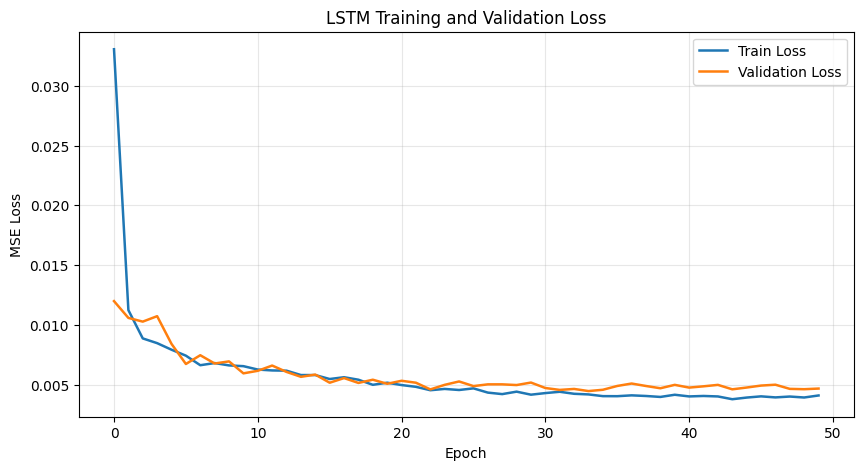

In [12]:
# ==========================================
# 6. 训练损失曲线 (Training Loss Curve)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=1.8)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=1.8)
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# ==========================================
# 7. 预测与结果反归一化 (Prediction & Inverse Transform)
# ==========================================
# 用测试集预测
predictions_scaled = model.predict(X_test)

# 将预测出的 [0, 1] 值还原回真实的功率瓦数
predictions = scaler_y.inverse_transform(predictions_scaled)
actuals = scaler_y.inverse_transform(y_test)

print('预测结果形状:', predictions.shape)
print('真实结果形状:', actuals.shape)

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
预测结果形状: (1936, 1)
真实结果形状: (1936, 1)


In [ ]:
# ==========================================
# 8. MAE / RMSE 评估 (Evaluation Metrics)
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"该站点最大功率: {df['power'].max():.4f}")

MAE  : 1.5499
RMSE : 2.3784
该站点最大功率: 35.1181


/Users/dazhaxie/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dazhaxie/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dazhaxie/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dazhaxie/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dazhaxie/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170:

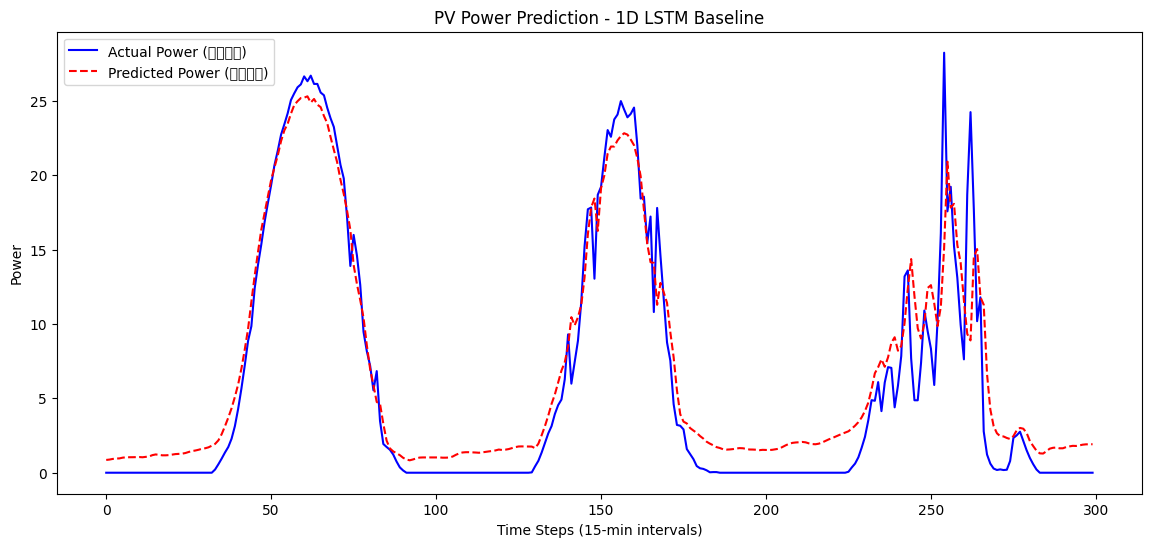

In [15]:
# ==========================================
# 9. 可视化结果 (Visualization)
# ==========================================
# 画出最后 300 个时间步（约 3 天）的对比图
plt.figure(figsize=(14, 6))
plt.plot(actuals[-300:], label='Actual Power (真实功率)', color='blue', linewidth=1.5)
plt.plot(predictions[-300:], label='Predicted Power (预测功率)', color='red', linestyle='--', linewidth=1.5)
plt.title('PV Power Prediction - 1D LSTM Baseline')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power')
plt.legend()
plt.show()